In [3]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Sequential

import warnings
warnings.filterwarnings('ignore')

In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step


In [5]:
X_train.shape

(60000, 28, 28)

In [6]:
y_train.shape

(60000,)

In [7]:
X_test.shape

(10000, 28, 28)

In [8]:
y_test.shape

(10000,)

In [25]:
#print(keras.datasets.mnist.load_data())
# # print(len(keras.datasets.mnist.load_data()))

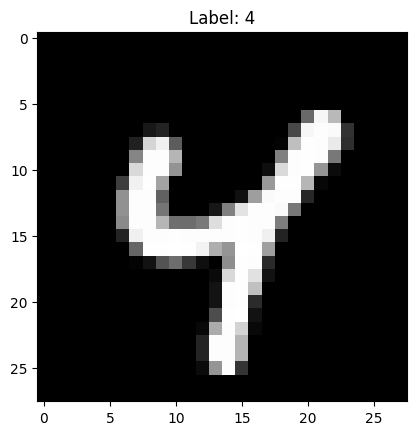

In [26]:
# Lets see visually how digit looks like

plt.imshow(X_train[1008], cmap='gray')
plt.title(f"Label: {y_train[1008]}")
plt.show()

In [11]:
X_train[1008]


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [12]:
# Lets normalise the data , in this case need to divide data by 255.0
# Large values → unstable learning
# So we scale to: 0 to 1
# Neural networks learn better with smaller values also improves accuracy

X_train = X_train / 255.0   # converts values between 0 and 1
X_test = X_test / 255.0     # converts values between 0 and 1

In [13]:
X_train[1008]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [14]:
# ANN doesn’t understand images directly → we convert to vector
# so need to convert image (28x28) into 1D vector
# (not dataset, it will be 2D)

X_train_flattened = X_train.reshape(-1, 784) 
X_test_flattened = X_test.reshape(-1, 784)

In [15]:
X_train_flattened

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784))

In [16]:
# Lets build model
# used dropout to reduce overfitting

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),  # Dense(128) -> 128 neurons active
    Dropout(0.2),                                       # 128 neurons -> ~102 active, random ~26 neurons OFF
    Dense(64, activation='relu'),                       # Outputs from remaining active neurons
    Dropout(0.2),                                       # 64 neurons -> ~51 active, random ~13 neurons OFF
    Dense(32, activation='relu'),                       # Outputs from remaining active neurons
    Dropout(0.2),                                       # 32 -> ~26 active,random ~6 neurons OFF
    Dense(10, activation='sigmoid')                     # Outputs from remaining active neurons
])

# compile model
# optimizer = 'adam' Automatically adjusts learning rate Works well in most cases

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# Lets train model
# epochs=5 ,Entire dataset is passed 5 times
model.fit(X_train_flattened, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.8732 - loss: 0.4355
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9438 - loss: 0.2021
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9558 - loss: 0.1584
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9618 - loss: 0.1362
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9666 - loss: 0.1192


In [17]:
# Lets evaluate model  to check real performance (Test Accuracy)
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9754 - loss: 0.0865


[0.08654135465621948, 0.9753999710083008]

In [18]:
y_predict = model.predict(X_test_flattened)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [27]:
y_predict[1008]

array([2.5995801e-05, 9.9999982e-01, 4.6644516e-02, 1.5119200e-02,
       8.5896921e-01, 3.8484915e-03, 2.8703053e-04, 3.6570653e-01,
       5.8585393e-01, 1.0487564e-03], dtype=float32)

In [28]:
print(np.argmax(y_predict[1008]))

1


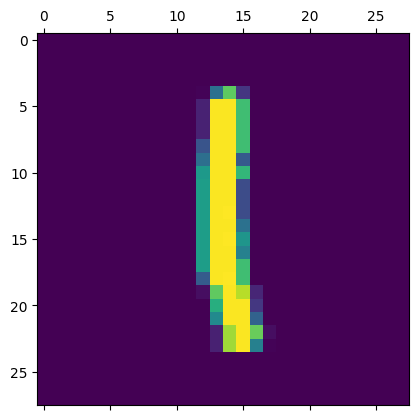

In [30]:
plt.matshow(X_test[1008])


In [22]:
# Now lets export model using keras
model.save("digit_recognition_model.keras")